In [17]:
import numpy as np
from aed_rate.electronic.potential import create_oh_system_acharya
from aed_rate.electronic.wavefunctions import ElectronicStructure
from aed_rate.electronic.coupling import ElectronicCoupling, InterpolatedCoupling
from aed_rate.nuclear.nuclear_wavefunction import create_wavefunction_solver
from aed_rate.utils.constants import CONSTANTS, get_reduced_mass
from aed_rate.utils import plotting

In [2]:
anion, neutral, EA = create_oh_system_acharya()
mu = get_reduced_mass("O", "H")
E  = CONSTANTS.cm1_to_hartree(66.0)

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Potential Energy Curves: O$^-$ + H System'}, xlabel='R (Bohr)', ylabel='Energy (eV)'>)

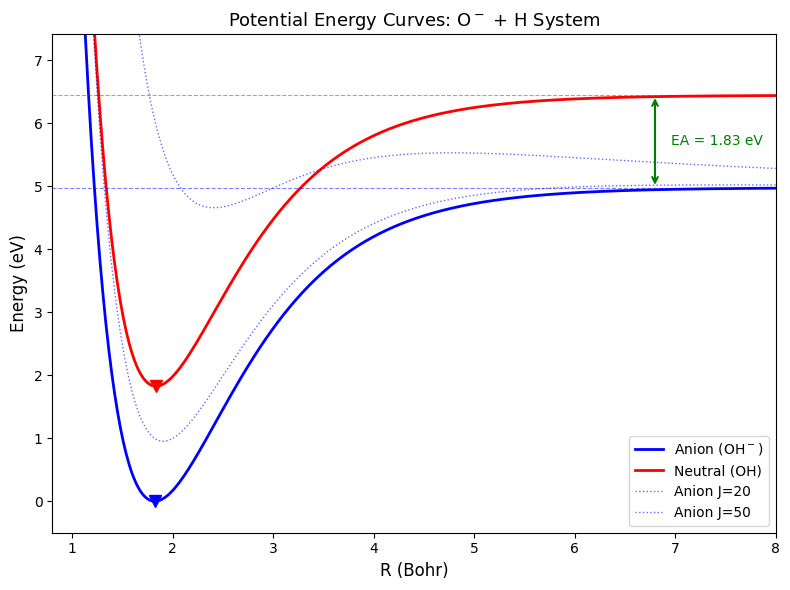

In [11]:
# 1. Potential energy curves
plotting.plot_potential_curves(anion, neutral, EA, reduced_mass=mu, J_values=[20, 50])

(<Figure size 800x600 with 2 Axes>,
 array([<Axes: title={'center': 'Scattering state: E = 66 cm⁻¹, J = 0'}, ylabel='$F_E(R)$'>,
        <Axes: xlabel='R (Bohr)', ylabel='$dF_E/dR$'>], dtype=object))

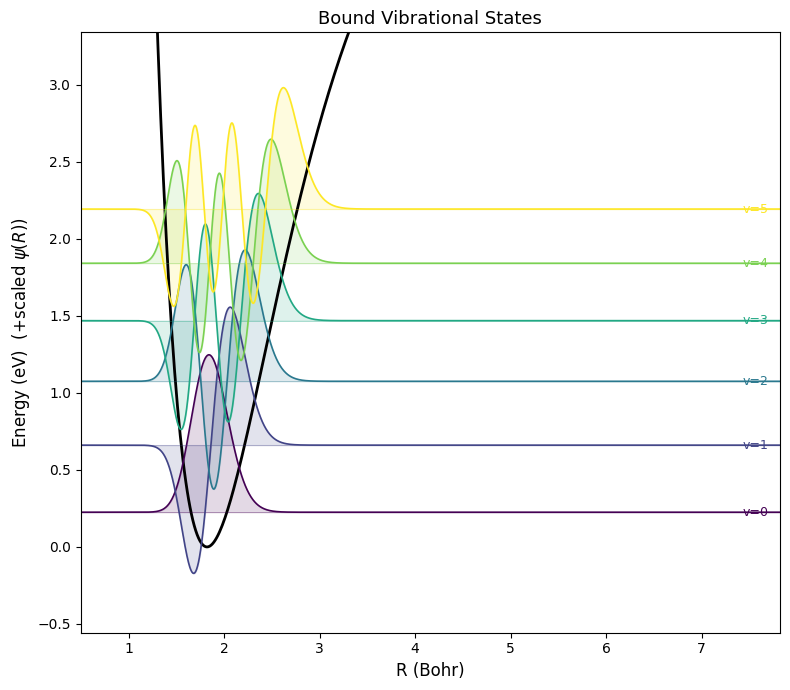

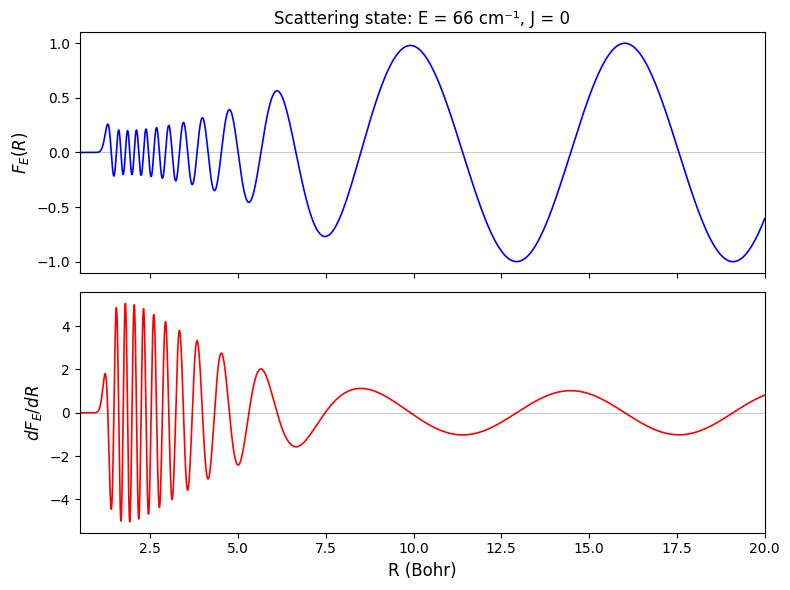

In [12]:

# 2. Nuclear wavefunctions (bound χ_{v'}, scattering F_E, and dF_E/dR)
solver = create_wavefunction_solver(anion, mu, method="morse", n_grid=6000)
bound  = solver.solve_bound_state(v=0, J=0)
scatt  = solver.solve_scattering_state(E, J=0, normalization="unit_amplitude")
dF_dR  = solver.wavefunction_derivative(scatt)
plotting.plot_bound_states(solver.solve_all_bound_states(J=0), anion)
plotting.plot_scattering_derivative(scatt, dF_dR)

converged SCF energy = -75.4052714518805


(<Figure size 1100x900 with 8 Axes>,
 array([[<Axes: title={'center': '$\\partial\\varphi_{\\rm HOMO}/\\partial R$'}, ylabel='x (Bohr)'>,
         <Axes: title={'center': '$\\partial\\varphi_{\\rm HOMO}/\\partial\\theta$'}>],
        [<Axes: title={'center': 'OPW $\\varphi_k$ (radial channel)'}, xlabel='z — bond axis (Bohr)', ylabel='x (Bohr)'>,
         <Axes: title={'center': 'OPW $\\varphi_k$ (rotational channel)'}, xlabel='z — bond axis (Bohr)'>]],
       dtype=object))

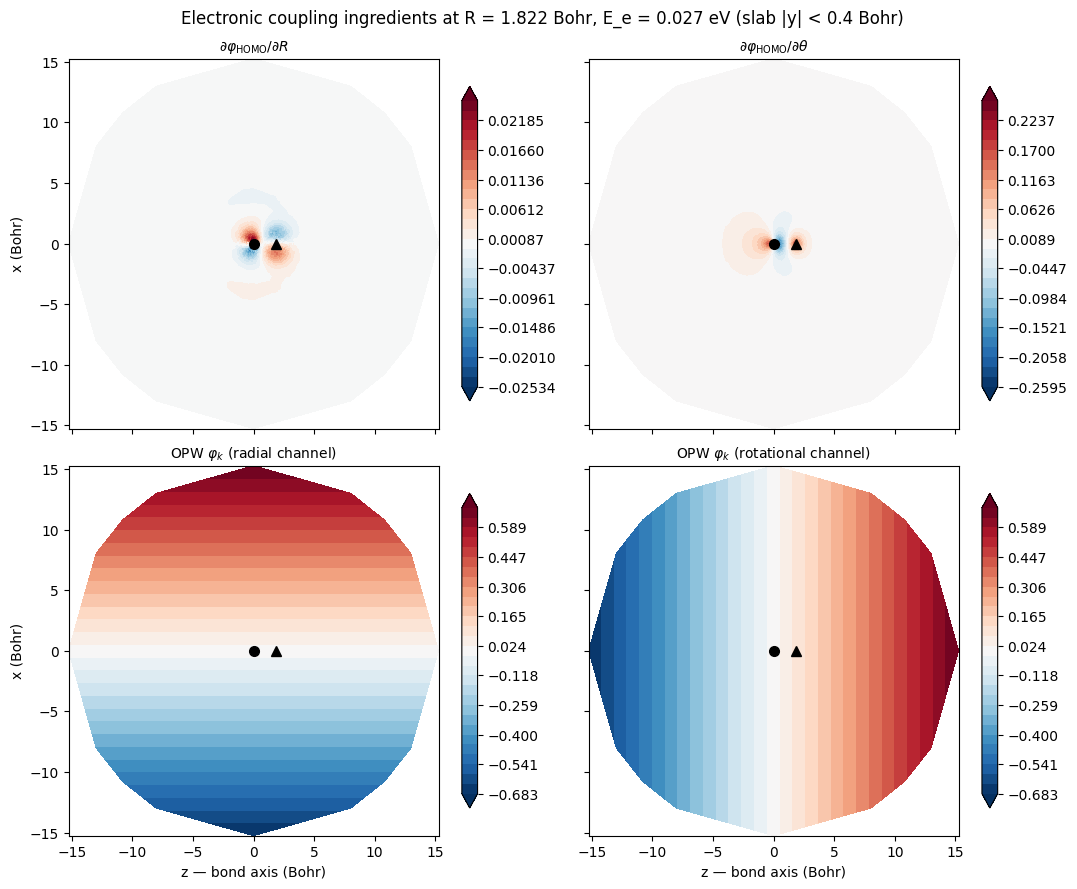

In [ ]:
# 3. Electronic coupling m_rad(R), m_rot(R) and its real-space ingredients
coupling = ElectronicCoupling(ElectronicStructure("O", "H", basis="6-311+G**"),
                              homo_symmetry="pi")
m   = coupling.compute_coupling_at_r(R=1.822, electron_energy=0.001)   # m_rad, m_rot
ing = coupling.compute_coupling_intermediates(R=1.822, electron_energy=0.001)
plotting.plot_electronic_intermediates(ing)        # ∂φ_HOMO/∂R and the OPW φ_k

(<Figure size 800x800 with 2 Axes>,
 array([<Axes: title={'center': 'Coupling integrand and its phase cancellation'}, ylabel='integrand $g(R)=\\chi\\, m_{\\rm rad}\\, dF_E/dR$'>,
        <Axes: xlabel='R (Bohr)', ylabel="$\\int^R\\! g\\,dR' / \\int^\\infty\\! g\\,dR'$">],
       dtype=object))

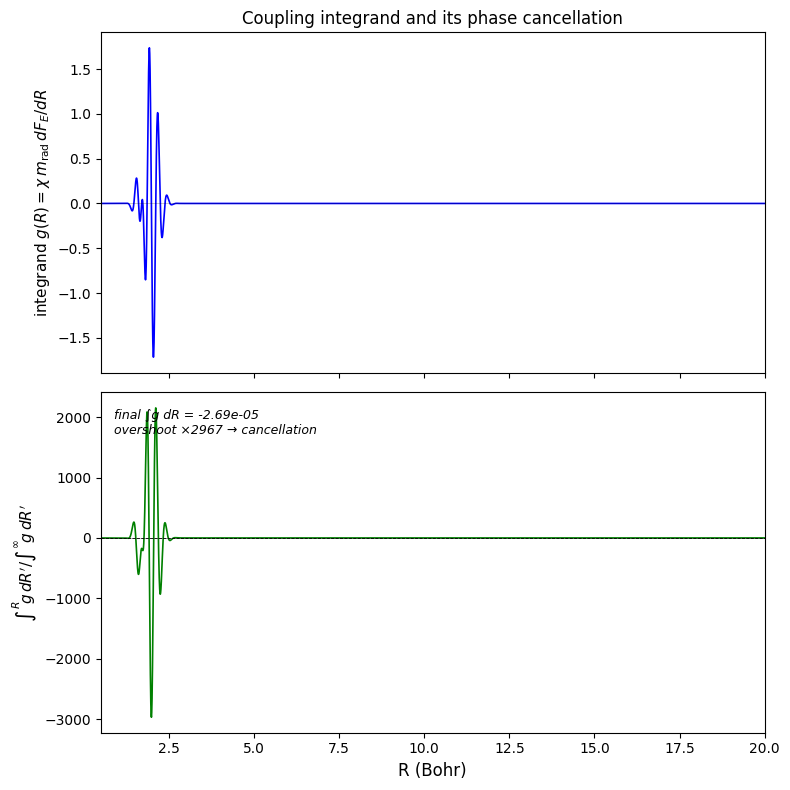

In [28]:
# The coupling integrand χ·m_rad·dF_E/dR (and its cancellation)

# prcompute couplings
#coupling.precompute()
#coupling.save("oh_coupling.npz")

coupling = InterpolatedCoupling.from_npz("oh_minus_coupling_aug-cc-pvdz.npz")
m_rad_R = np.array([coupling.compute_coupling_at_r(R, 0.01).m_rad.real
                    for R in solver.r_grid])

plotting.plot_coupling_integrand(solver.r_grid, bound.wavefunction, m_rad_R, dF_dR)